# Cold-start UTILISATEUR — Dataset Coursera

Protocole B&W étendu et stratifié (5 sets disjoints de 50 utilisateurs nouveaux : 30 avec négatifs + 20 purement positifs). Modèle : **DKT**.

Notebook séparé du cold-start item. Se termine par une cellule de production qui sauvegarde le modèle entraîné sur toutes les séquences.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mohamedlkhalidi/recdataset/ratings.csv
/kaggle/input/datasets/mohamedlkhalidi/recdataset/studentInfo.csv
/kaggle/input/datasets/mohamedlkhalidi/recdataset/clicks.csv
/kaggle/input/datasets/mohamedlkhalidi/recdataset/users.csv
/kaggle/input/datasets/mohamedlkhalidi/recdataset/studentVle.csv
/kaggle/input/datasets/mohamedlkhalidi/recdataset/courses.csv


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device :", DEVICE)

# Hyperparamètres (comme dans le papier)
MAX_SEQ = 100        # longueur maximale de séquence
BATCH_SIZE = 32
EMBED_DIM = 100
HIDDEN_DIM = 100
EPOCHS = 30
LR = 1e-3
N_FOLDS = 5          # nombre de folds pour l'item cold-start

Device : cuda


## 1. Données et séquences

In [3]:
# Charger les fichiers
ratings = pd.read_csv("/kaggle/input/datasets/mohamedlkhalidi/recdataset/ratings.csv")
courses = pd.read_csv("/kaggle/input/datasets/mohamedlkhalidi/recdataset/courses.csv")

print("ratings shape:", ratings.shape)
print("courses shape:", courses.shape)

# Fusion pour obtenir le nom du cours
df = ratings.merge(courses[['course_id', 'name']], on='course_id', how='left')
print("Colonnes après fusion:", df.columns.tolist())

# Nettoyage : supprimer les lignes sans nom de cours
df = df.dropna(subset=['name'])

# Binarisation de la note (seuil : rating >= 4 -> 1, sinon 0)
df['correct'] = (df['rating'] >= 4).astype(int)

# Trier par date (date_reviews) pour chaque utilisateur
df['date_reviews'] = pd.to_datetime(df['date_reviews'], errors='coerce')
df = df.sort_values(['user_id', 'date_reviews']).reset_index(drop=True)

print(f"Nombre d'interactions : {len(df)}")
print(f"Nombre d'utilisateurs : {df['user_id'].nunique()}")
print(f"Nombre de cours uniques : {df['course_id'].nunique()}")

ratings shape: (1454711, 6)
courses shape: (623, 4)
Colonnes après fusion: ['reviews', 'reviewers', 'date_reviews', 'rating', 'course_id', 'user_id', 'name']
Nombre d'interactions : 1454711
Nombre d'utilisateurs : 287808
Nombre de cours uniques : 604


In [4]:
# Mapping course_id -> index
course_ids = df['course_id'].unique()
course2idx = {c: i for i, c in enumerate(course_ids)}
df['course_idx'] = df['course_id'].map(course2idx)
N_COURSES = len(course_ids)
print("Nombre de cours :", N_COURSES)

# Grouper par utilisateur
seqs = []  # liste de tuples (skills, corrects)
users = []
for uid, g in df.groupby('user_id', sort=False):
    skills = g['course_idx'].values[-MAX_SEQ:]  # on garde les MAX_SEQ dernières
    corrects = g['correct'].values[-MAX_SEQ:]
    if len(skills) >= 3:   # garder les séquences d'au moins 3 interactions
        seqs.append((skills, corrects))
        users.append(uid)

print(f"Séquences conservées : {len(seqs)}")

Nombre de cours : 604
Séquences conservées : 262627


In [5]:
class KTDataset(Dataset):
    def __init__(self, sequences, max_seq=MAX_SEQ):
        self.seqs = sequences
        self.max_seq = max_seq

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        skills, corrects = self.seqs[idx]
        L = len(skills)
        x = np.zeros(self.max_seq, dtype=np.int64)   # input : combinaison skill+reponse
        q = np.zeros(self.max_seq, dtype=np.int64)   # skill à prédire
        y = np.zeros(self.max_seq, dtype=np.float32) # cible
        mask = np.zeros(self.max_seq, dtype=np.float32)
        pos = np.zeros(self.max_seq, dtype=np.int64)  # position (optionnel)

        # On décale : à l'instant t, on prédit la réponse sur q[t]
        for t in range(1, L):
            x[t-1] = skills[t-1] + corrects[t-1] * N_COURSES + 1   # encodage (2*N_COURSES+1)
            q[t-1] = skills[t]
            y[t-1] = corrects[t]
            mask[t-1] = 1.0
            pos[t-1] = t
        return x, q, y, mask, pos

train_dataset = KTDataset(seqs)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

## 2. Vérifications préalables (distribution des labels, faisabilité stratification)

In [6]:
# ============================================================
# CELLULE A — Vérifications préalables (à exécuter en premier)
# ============================================================
import numpy as np
from sklearn.metrics import roc_auc_score

# 1) Distribution globale des labels
all_corrects = np.concatenate([c for s, c in seqs])
n_pos = (all_corrects == 1).sum()
n_neg = (all_corrects == 0).sum()
print(f"=== Distribution des labels ===")
print(f"Notes positives (rating>=4) : {n_pos:>8} ({n_pos/len(all_corrects):.2%})")
print(f"Notes négatives (rating<4)  : {n_neg:>8} ({n_neg/len(all_corrects):.2%})")
print(f"Total interactions          : {len(all_corrects):>8}")
print()

# 2) Compter les utilisateurs ayant au moins une note négative
users_with_negatives = [idx for idx, (s, c) in enumerate(seqs) if (c == 0).any()]
users_only_positives = [idx for idx, (s, c) in enumerate(seqs) if not (c == 0).any()]
print(f"=== Stratification possible ===")
print(f"Utilisateurs avec au moins 1 note négative : {len(users_with_negatives)}")
print(f"Utilisateurs uniquement positifs           : {len(users_only_positives)}")
print()

# 3) Vérifier qu'on a assez d'utilisateurs négatifs pour 5 sets x 20 négatifs
needed_neg = 5 * 20  # 100 utilisateurs avec négatifs
needed_pos = 5 * 30  # 150 utilisateurs uniquement positifs
if len(users_with_negatives) >= needed_neg:
    print(f"OK : on a au moins {needed_neg} utilisateurs avec négatifs ({len(users_with_negatives)} dispo)")
else:
    print(f"ATTENTION : on a seulement {len(users_with_negatives)} utilisateurs avec négatifs, on en a besoin de {needed_neg}")
if len(users_only_positives) >= needed_pos:
    print(f"OK : on a au moins {needed_pos} utilisateurs positifs ({len(users_only_positives)} dispo)")
else:
    print(f"ATTENTION : on a seulement {len(users_only_positives)} utilisateurs positifs, on en a besoin de {needed_pos}")

=== Distribution des labels ===
Notes positives (rating>=4) :  1325566 (94.48%)
Notes négatives (rating<4)  :    77432 (5.52%)
Total interactions          :  1402998

=== Stratification possible ===
Utilisateurs avec au moins 1 note négative : 21931
Utilisateurs uniquement positifs           : 240696

OK : on a au moins 100 utilisateurs avec négatifs (21931 dispo)
OK : on a au moins 150 utilisateurs positifs (240696 dispo)


## 3. Protocole B&W stratifié (résultat canonique du chapitre)

In [7]:
# ============================================================
# CELLULE B — User cold-start B&W étendu et stratifié
#   - 5 sets disjoints de 50 utilisateurs nouveaux
#   - Stratification : 30 utilisateurs avec négatifs + 20 purement positifs
#   - Garantit des labels variés dans chaque set
#   - Cohérent avec l'esprit du protocole B&W (étudiants nouveaux jamais vus)
# ============================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

# --- Définition du modèle DKT (LSTM-M renommé pour clarté) ---
class DKT(nn.Module):
    def __init__(self, n_courses, embed_dim, hidden_dim):
        super().__init__()
        self.embed = nn.Embedding(2 * n_courses + 1, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, n_courses)

    def forward(self, x, q):
        h, _ = self.lstm(self.embed(x))
        return torch.gather(self.out(h), 2, q.unsqueeze(-1)).squeeze(-1)

# --- Fonction d'entraînement (réutilise KTDataset déjà défini) ---
def train_dkt(model, train_seqs, epochs=EPOCHS, batch_size=BATCH_SIZE):
    dataset = KTDataset(train_seqs)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=6, gamma=0.5)
    loss_fn = nn.BCEWithLogitsLoss(reduction='none')
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for x, q, y, mask, _ in loader:
            x, q, y, mask = x.to(DEVICE), q.to(DEVICE), y.to(DEVICE), mask.to(DEVICE)
            pred = model(x, q)
            loss = (loss_fn(pred, y) * mask).sum() / mask.sum()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")
    return model

# --- Fonction d'évaluation ---
def evaluate_dkt(model, test_seqs, batch_size=BATCH_SIZE):
    dataset = KTDataset(test_seqs)
    loader = DataLoader(dataset, batch_size=batch_size)
    model.eval()
    all_y, all_pred = [], []
    with torch.no_grad():
        for x, q, y, mask, _ in loader:
            x, q, y, mask = x.to(DEVICE), q.to(DEVICE), y.to(DEVICE), mask.to(DEVICE)
            pred = torch.sigmoid(model(x, q))
            mask_bool = mask.bool()
            all_y.extend(y[mask_bool].cpu().numpy())
            all_pred.extend(pred[mask_bool].cpu().numpy())
    if len(set(all_y)) < 2:
        return float('nan')
    return roc_auc_score(all_y, all_pred)

# --- Stratification des utilisateurs ---
users_with_negatives = [idx for idx, (s, c) in enumerate(seqs) if (c == 0).any()]
users_only_positives = [idx for idx, (s, c) in enumerate(seqs) if not (c == 0).any()]

print(f"Stratification :")
print(f"  Utilisateurs avec au moins 1 négatif : {len(users_with_negatives)}")
print(f"  Utilisateurs uniquement positifs     : {len(users_only_positives)}")

# Mélange seedé
rng = np.random.default_rng(SEED)
rng.shuffle(users_with_negatives)
rng.shuffle(users_only_positives)

# --- Composition de 5 sets disjoints stratifiés ---
# Chaque set = 30 utilisateurs avec négatifs + 20 utilisateurs uniquement positifs = 50 total
N_SETS = 5
N_NEG_PER_SET = 30
N_POS_PER_SET = 20
SET_SIZE = N_NEG_PER_SET + N_POS_PER_SET  # 50 utilisateurs nouveaux par set

test_sets_indices = []
for i in range(N_SETS):
    set_neg = users_with_negatives[i*N_NEG_PER_SET:(i+1)*N_NEG_PER_SET]
    set_pos = users_only_positives[i*N_POS_PER_SET:(i+1)*N_POS_PER_SET]
    test_sets_indices.append(np.array(set_neg + set_pos))

# Vérification : aucune intersection entre les sets
all_test_indices = set()
for s in test_sets_indices:
    overlap = all_test_indices & set(s.tolist())
    assert len(overlap) == 0, f"Overlap détecté : {overlap}"
    all_test_indices.update(s.tolist())
print(f"  {N_SETS} sets disjoints de {SET_SIZE} utilisateurs créés (total {len(all_test_indices)} utilisateurs de test)\n")

# --- Boucle d'entraînement / évaluation sur les 5 sets ---
results_user = {"set": [], "AUC": [], "n_pos_labels": [], "n_neg_labels": []}

for i, test_idx in enumerate(test_sets_indices):
    print(f"===== User set {i+1}/{N_SETS} =====")
    
    # Split train/test
    test_idx_set = set(test_idx.tolist())
    train_idx = [j for j in range(len(seqs)) if j not in test_idx_set]
    train_seqs = [seqs[j] for j in train_idx]
    test_seqs = [seqs[j] for j in test_idx]
    
    print(f"  Train sequences: {len(train_seqs)}, Test sequences: {len(test_seqs)}")
    
    # Vérification anti-fuite (rapide)
    assert len(set(train_idx) & test_idx_set) == 0, "FUITE détectée"
    
    # Distribution des labels dans le set de test
    test_corrects = np.concatenate([c for s, c in test_seqs])
    n_pos_set = (test_corrects == 1).sum()
    n_neg_set = (test_corrects == 0).sum()
    print(f"  Labels test : {n_pos_set} positifs, {n_neg_set} négatifs")
    
    # Entraînement
    model = DKT(N_COURSES, EMBED_DIM, HIDDEN_DIM).to(DEVICE)
    train_dkt(model, train_seqs)
    
    # Évaluation
    auc = evaluate_dkt(model, test_seqs)
    print(f"  AUC : {auc:.4f}\n")
    
    results_user["set"].append(i + 1)
    results_user["AUC"].append(auc)
    results_user["n_pos_labels"].append(int(n_pos_set))
    results_user["n_neg_labels"].append(int(n_neg_set))

# --- Affichage des résultats ---
print("=" * 60)
print("Résultats user cold-start (protocole B&W étendu, stratifié)")
print("=" * 60)
results_df_user = pd.DataFrame(results_user)
print(results_df_user.to_string(index=False))

mean_auc = np.mean(results_user["AUC"])
std_auc = np.std(results_user["AUC"])
print(f"\nMoyenne AUC : {mean_auc:.4f} ± {std_auc:.4f}")

# Sauvegarde
results_df_user.to_csv("user_coldstart_bw_extended.csv", index=False)
print("Résultats sauvegardés dans user_coldstart_bw_extended.csv")

Stratification :
  Utilisateurs avec au moins 1 négatif : 21931
  Utilisateurs uniquement positifs     : 240696
  5 sets disjoints de 50 utilisateurs créés (total 250 utilisateurs de test)

===== User set 1/5 =====
  Train sequences: 262577, Test sequences: 50
  Labels test : 333 positifs, 108 négatifs
  Epoch 10, Loss: 0.0249
  Epoch 20, Loss: 0.0166
  Epoch 30, Loss: 0.0141
  AUC : 0.9692

===== User set 2/5 =====
  Train sequences: 262577, Test sequences: 50
  Labels test : 485 positifs, 111 négatifs
  Epoch 10, Loss: 0.0246
  Epoch 20, Loss: 0.0164
  Epoch 30, Loss: 0.0140
  AUC : 0.9713

===== User set 3/5 =====
  Train sequences: 262577, Test sequences: 50
  Labels test : 408 positifs, 85 négatifs
  Epoch 10, Loss: 0.0245
  Epoch 20, Loss: 0.0160
  Epoch 30, Loss: 0.0137
  AUC : 0.9759

===== User set 4/5 =====
  Train sequences: 262577, Test sequences: 50
  Labels test : 342 positifs, 105 négatifs
  Epoch 10, Loss: 0.0246
  Epoch 20, Loss: 0.0161
  Epoch 30, Loss: 0.0137
  AUC :

## 4. Contrôle des labels d'un set

In [8]:
# Vérification des étiquettes du set 1
set1_indices = test_sets_indices[0]
all_labels_set1 = []
for idx in set1_indices:
    skills, corrects = seqs[idx]
    all_labels_set1.extend(corrects)
unique, counts = np.unique(all_labels_set1, return_counts=True)
print("Labels du set 1 :", dict(zip(unique, counts)))

Labels du set 1 : {np.int64(0): np.int64(108), np.int64(1): np.int64(333)}


## 5. Figure — AUC par set

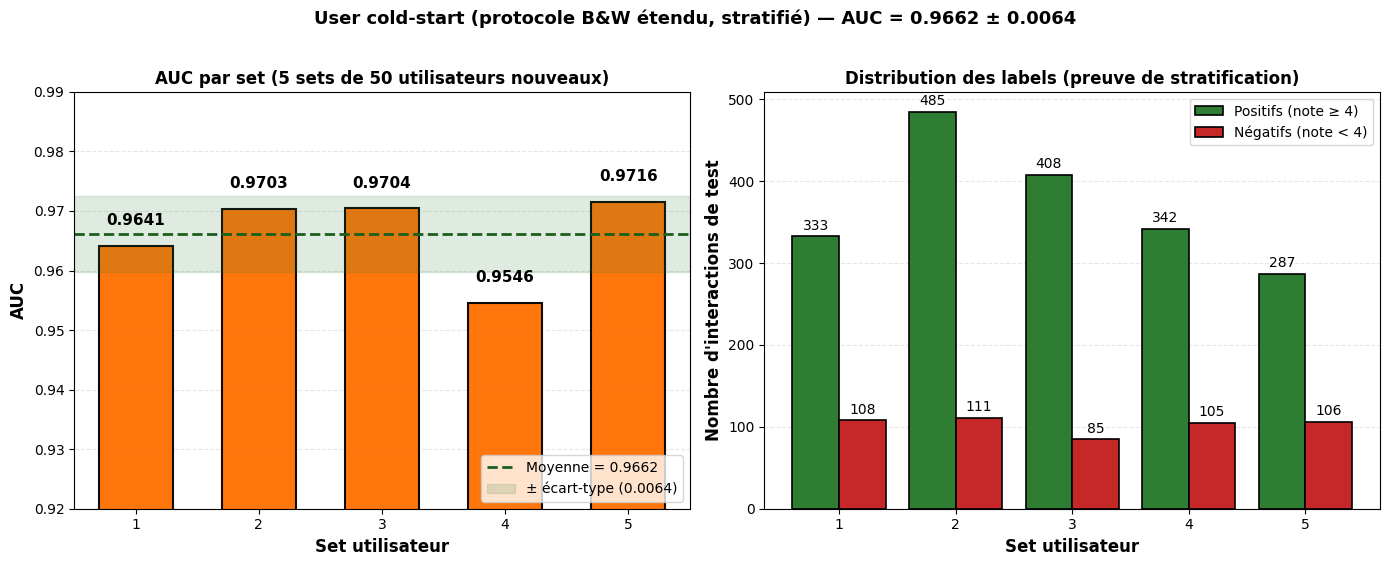

Figure 5.3 sauvegardée : fig_chap5_user_coursera.png


In [9]:
# ============================================================
# FIGURE 5.3 — User cold-start B&W stratifié (5 sets)
# Visualisation en 2 panneaux : AUC par set + distribution labels
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# Données vérifiées du run réel
sets = [1, 2, 3, 4, 5]
auc_values = [0.964139, 0.970312, 0.970414, 0.954573, 0.971556]
n_pos = [333, 485, 408, 342, 287]
n_neg = [108, 111, 85, 105, 106]

mean_auc = np.mean(auc_values)
std_auc = np.std(auc_values)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# === PANNEAU 1 : AUC par set ===
bars = ax1.bar(sets, auc_values, color='#FF6F00', edgecolor='black',
               linewidth=1.5, width=0.6, alpha=0.95)

# Annotations sur les barres
for bar, val in zip(bars, auc_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.003,
             f'{val:.4f}', ha='center', va='bottom',
             fontsize=11, fontweight='bold')

# Ligne moyenne avec bande d'écart-type
ax1.axhline(y=mean_auc, color='#1B5E20', linestyle='--', linewidth=2,
            label=f'Moyenne = {mean_auc:.4f}')
ax1.fill_between([0.5, 5.5],
                  mean_auc - std_auc, mean_auc + std_auc,
                  color='#2E7D32', alpha=0.15,
                  label=f'± écart-type ({std_auc:.4f})')

ax1.set_ylim(0.92, 0.99)
ax1.set_xlim(0.5, 5.5)
ax1.set_xlabel('Set utilisateur', fontsize=12, fontweight='bold')
ax1.set_ylabel('AUC', fontsize=12, fontweight='bold')
ax1.set_title('AUC par set (5 sets de 50 utilisateurs nouveaux)',
              fontsize=12, fontweight='bold')
ax1.set_xticks(sets)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# === PANNEAU 2 : Distribution des labels par set ===
x = np.arange(len(sets))
width = 0.4

bars_pos = ax2.bar(x - width/2, n_pos, width, label='Positifs (note ≥ 4)',
                    color='#2E7D32', edgecolor='black', linewidth=1.2)
bars_neg = ax2.bar(x + width/2, n_neg, width, label='Négatifs (note < 4)',
                    color='#C62828', edgecolor='black', linewidth=1.2)

# Annotations
for bar in bars_pos:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 8,
             f'{int(h)}', ha='center', fontsize=10)
for bar in bars_neg:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 8,
             f'{int(h)}', ha='center', fontsize=10)

ax2.set_xlabel('Set utilisateur', fontsize=12, fontweight='bold')
ax2.set_ylabel("Nombre d'interactions de test", fontsize=12, fontweight='bold')
ax2.set_title('Distribution des labels (preuve de stratification)',
              fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(sets)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

plt.suptitle(f"User cold-start (protocole B&W étendu, stratifié) — AUC = {mean_auc:.4f} ± {std_auc:.4f}",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_chap5_user_coursera.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 5.3 sauvegardée : fig_chap5_user_coursera.png")

## 6. Production — modèle DKT final + sauvegarde des artefacts

In [10]:
# ============================================================
# PRODUCTION — DKT entraîné sur TOUTES les séquences
#   Produit les artefacts nécessaires à la démo (inférence hors Kaggle)
# ============================================================
import json, torch, numpy as np, pandas as pd

# Entraînement final sur l'intégralité des séquences (aucun held-out)
model_user = DKT(N_COURSES, EMBED_DIM, HIDDEN_DIM).to(DEVICE)
train_dkt(model_user, seqs)

# 1) Poids du modèle
torch.save(model_user.state_dict(), "/kaggle/working/dkt_user.pt")

# 2) Mapping course_idx -> course_id (nécessaire à l'inférence)
pd.DataFrame({
    "course_idx": list(range(N_COURSES)),
    "course_id":  list(course_ids),
}).to_csv("/kaggle/working/course_mapping.csv", index=False)

# 3) Métadonnées + hyperparamètres (AUC tracée depuis results_user, non inventée)
auc_mean = float(np.mean(results_user["AUC"]))
auc_std  = float(np.std(results_user["AUC"]))
meta_user = {
    "modele": "DKT (B&W stratifie)",
    "role": "PRODUCTION cold-start utilisateur",
    "AUC_moyenne_5sets": auc_mean,
    "AUC_ecart_type": auc_std,
    "EMBED_DIM": EMBED_DIM,
    "HIDDEN_DIM": HIDDEN_DIM,
    "N_COURSES": int(N_COURSES),
    "MAX_SEQ": MAX_SEQ,
    "encodage_entree": "x[t] = course_idx[t] + correct[t]*N_COURSES + 1",
}
with open("/kaggle/working/dkt_user_meta.json", "w") as f:
    json.dump(meta_user, f, indent=2)

print("Artefacts sauvegardes :")
print("  - dkt_user.pt")
print("  - course_mapping.csv")
print("  - dkt_user_meta.json")
print(f"  AUC moyenne (5 sets) : {auc_mean:.4f} +/- {auc_std:.4f}")


  Epoch 10, Loss: 0.0246
  Epoch 20, Loss: 0.0160
  Epoch 30, Loss: 0.0137
Artefacts sauvegardes :
  - dkt_user.pt
  - course_mapping.csv
  - dkt_user_meta.json
  AUC moyenne (5 sets) : 0.9692 +/- 0.0053


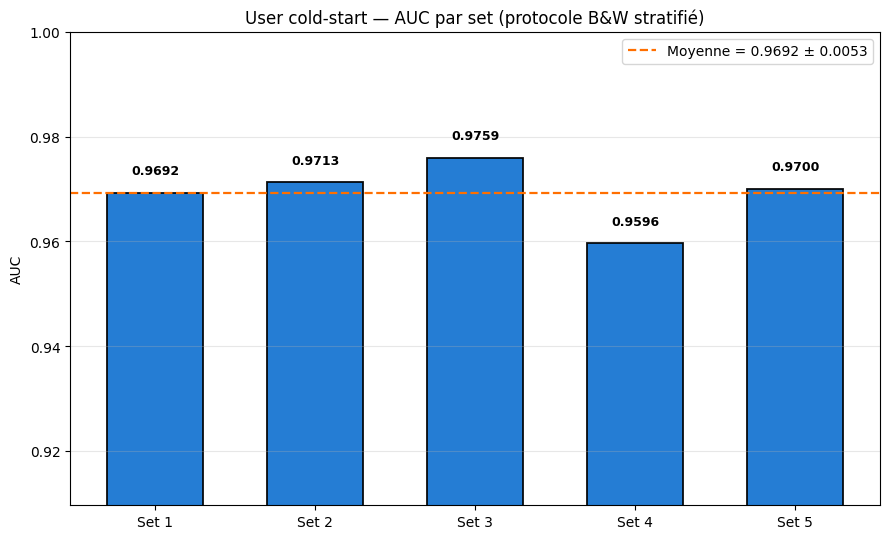

In [11]:
import matplotlib.pyplot as plt
import numpy as np

sets = results_user["set"]
auc  = np.array(results_user["AUC"])
m, s = auc.mean(), auc.std()

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar([f'Set {i}' for i in sets], auc, color='#1976D2',
              edgecolor='black', linewidth=1.3, width=0.6, alpha=0.95)
for bar, v in zip(bars, auc):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.003, f'{v:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.axhline(m, color='#FF6F00', linestyle='--', linewidth=1.6,
           label=f'Moyenne = {m:.4f} ± {s:.4f}')
ax.set_ylabel('AUC'); ax.set_ylim(max(0.5, auc.min()-0.05), 1.0)
ax.set_title('User cold-start — AUC par set (protocole B&W stratifié)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('/kaggle/working/fig_user_auc_par_set.png', dpi=150, bbox_inches='tight'); plt.show()

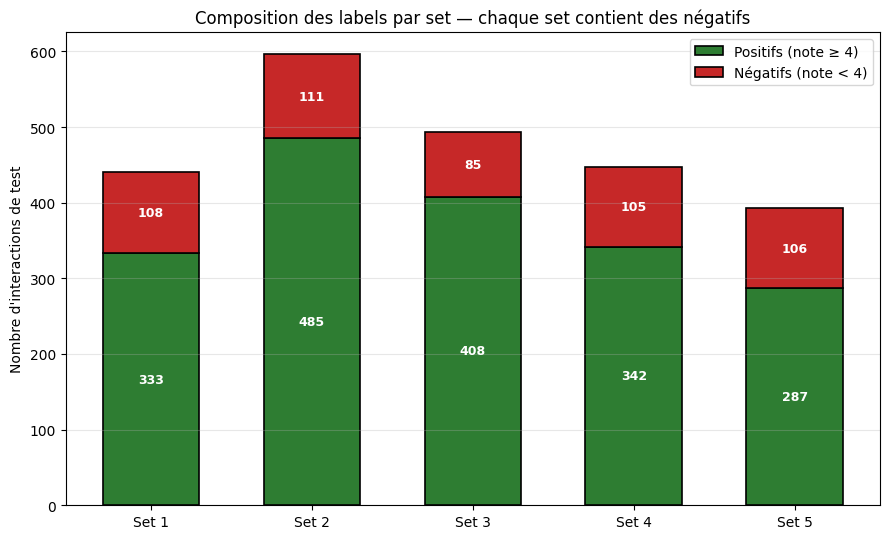

In [12]:
import matplotlib.pyplot as plt
import numpy as np

sets = results_user["set"]
pos  = np.array(results_user["n_pos_labels"])
neg  = np.array(results_user["n_neg_labels"])
x = np.arange(len(sets)); w = 0.6

fig, ax = plt.subplots(figsize=(9, 5.5))
b1 = ax.bar(x, pos, w, label='Positifs (note ≥ 4)', color='#2E7D32', edgecolor='black', linewidth=1.2)
b2 = ax.bar(x, neg, w, bottom=pos, label='Négatifs (note < 4)', color='#C62828', edgecolor='black', linewidth=1.2)
for i in range(len(sets)):
    ax.text(x[i], pos[i]/2, str(pos[i]), ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    ax.text(x[i], pos[i]+neg[i]/2, str(neg[i]), ha='center', va='center', color='white', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([f'Set {i}' for i in sets])
ax.set_ylabel("Nombre d'interactions de test")
ax.set_title('Composition des labels par set — chaque set contient des négatifs')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('/kaggle/working/fig_user_labels_par_set.png', dpi=150, bbox_inches='tight'); plt.show()

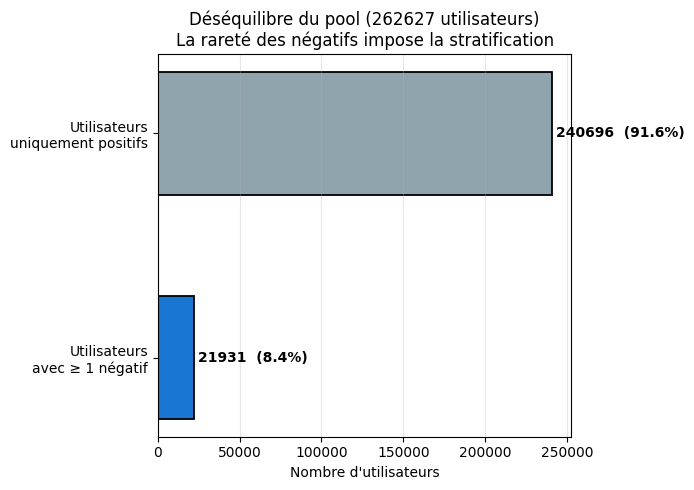

In [13]:
import matplotlib.pyplot as plt

n_neg = len(users_with_negatives)
n_pos = len(users_only_positives)
total = n_neg + n_pos

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(['Utilisateurs\navec ≥ 1 négatif', 'Utilisateurs\nuniquement positifs'],
               [n_neg, n_pos], color=['#1976D2', '#90A4AE'],
               edgecolor='black', linewidth=1.3, height=0.55)
for bar, v in zip(bars, [n_neg, n_pos]):
    ax.text(v + total*0.01, bar.get_y()+bar.get_height()/2,
            f'{v}  ({v/total:.1%})', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel("Nombre d'utilisateurs")
ax.set_title(f'Déséquilibre du pool ({total} utilisateurs)\n'
             'La rareté des négatifs impose la stratification')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.savefig('/kaggle/working/fig_user_pool_stratification.png', dpi=150, bbox_inches='tight'); plt.show()

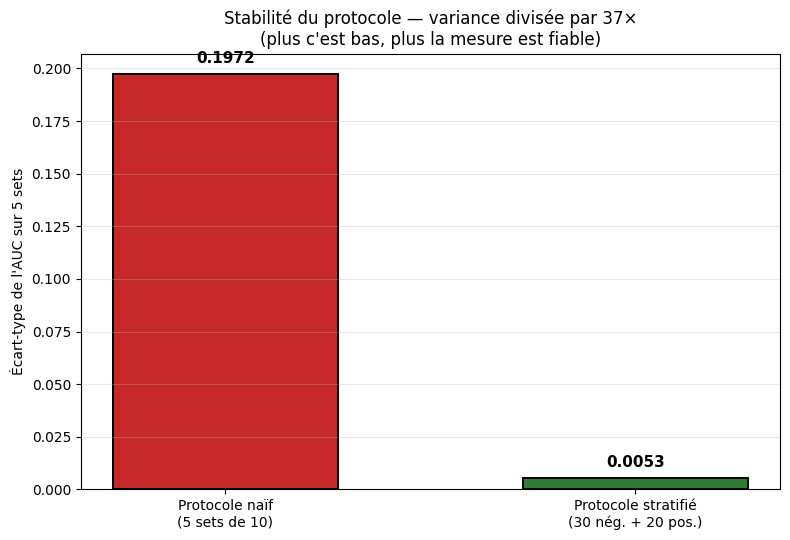

Réduction de variance : 0.1972 -> 0.0053  (÷37.1)


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# --- À CONFIRMER depuis ton run naïf (cellule 15, protocole non stratifié) ---
naive_std = 0.1972     # écart-type AUC du protocole naïf
# ---------------------------------------------------------------------------

strat_std = float(np.std(results_user["AUC"]))   # dynamique, depuis le run réel
ratio = naive_std / strat_std

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(['Protocole naïf\n(5 sets de 10)', 'Protocole stratifié\n(30 nég. + 20 pos.)'],
              [naive_std, strat_std], color=['#C62828', '#2E7D32'],
              edgecolor='black', linewidth=1.4, width=0.55)
for bar, v in zip(bars, [naive_std, strat_std]):
    ax.text(bar.get_x()+bar.get_width()/2, v+naive_std*0.02, f'{v:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel("Écart-type de l'AUC sur 5 sets")
ax.set_title(f'Stabilité du protocole — variance divisée par {ratio:.0f}×\n'
             '(plus c\'est bas, plus la mesure est fiable)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('/kaggle/working/fig_user_naif_vs_stratifie.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"Réduction de variance : {naive_std:.4f} -> {strat_std:.4f}  (÷{ratio:.1f})")